In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from scipy import stats
# load_boston 대신 fetch_california_housing로 대체
from sklearn.datasets import fetch_california_housing
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

# california 데이터세트 로드
california = fetch_california_housing()

# california 데이터세트 dataframe 변환
californiaDF = pd.DataFrame(california.data, columns = california.feature_names)

# target 배열은 주택 가격. 이를 PRICE 칼럼으로 dataframe에 추가함
californiaDF['PRICE'] = california.target 
print('데이터세트 크기:' , californiaDF.shape)
californiaDF.head()

데이터세트 크기: (20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,PRICE
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [9]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score

# alpha=10 으로 릿지 회귀 수행
ridge = Ridge(alpha = 10)
y_target = californiaDF['PRICE']
X_data = californiaDF.drop(['PRICE'],axis=1,inplace=False)
neg_mse_scores = cross_val_score(ridge, X_data, y_target, scoring='neg_mean_squared_error', cv=5)
rmse_scores = np.sqrt(-1 * neg_mse_scores) # rmse = root mean squared error 평균제곱근오차
avg_rmse = np.mean(rmse_scores)

print('5fold 개별 negative mse scores:', np.round(neg_mse_scores, 3))
print('5fold 개별 rmse scores:', np.round(rmse_scores,3))
print('5fold 의 평균 rmse:', avg_rmse)

5fold 개별 negative mse scores: [-0.484 -0.623 -0.646 -0.544 -0.494]
5fold 개별 rmse scores: [0.695 0.789 0.804 0.737 0.703]
5fold 의 평균 rmse: 0.7458207292972585


In [11]:
# 릿지에 사용될 alpha 파라미터 값을 정의
alphas = [0,0.1,1,10,100]

# alphas list 값을 반복하면서 alpha에 따른 평균 rmse를 구함
for alpha in alphas:
    ridge = Ridge(alpha = alpha)
    # cross_Val_score를 이용해 5폴드 평균 rmse를 계산
    neg_mse_scores = cross_val_score(ridge, X_data, y_target, scoring='neg_mean_squared_error', cv=5)
    avg_rmse = np.mean(np.sqrt(-1 * neg_mse_scores))
    print(f'alpha {alpha}일때 5fold 평균 rmse: {avg_rmse:.3f}')

alpha 0일때 5fold 평균 rmse: 0.746
alpha 0.1일때 5fold 평균 rmse: 0.746
alpha 1일때 5fold 평균 rmse: 0.746
alpha 10일때 5fold 평균 rmse: 0.746
alpha 100일때 5fold 평균 rmse: 0.746


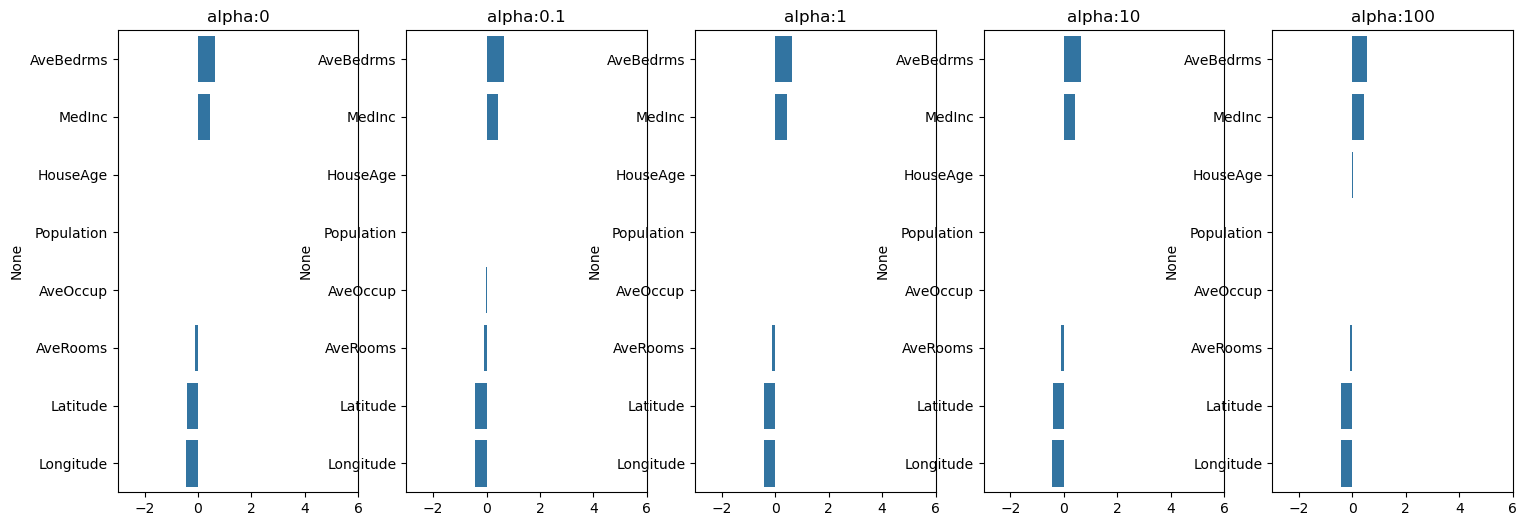

In [13]:
# 각 alpha에 따른 회귀 계수 값을 시각화하기 위해 5개의 열로 된 맷플롯립 축 생성
fig, axs = plt.subplots(figsize=(18,6), nrows=1, ncols=5)
# 각 alpha에 따른 회귀계수 값을 데이터로 저장하기 위한 Dataframe 생성
coeff_df =pd.DataFrame()

# alpha 리스트 값을 차례로 입력해 회귀 계수 값 시각화 및 데이터 저장. pos는 axis의 위치 지정
for pos, alpha in enumerate(alphas):
    ridge = Ridge(alpha = alpha)
    ridge.fit(X_data, y_target)
    # alpha에 따른 피처별로 회귀 계수를 series로 변환하고 이를 dataframe의 칼럼으로 추가
    coeff = pd.Series(data=ridge.coef_,index=X_data.columns)
    colname='alpha:'+str(alpha)
    coeff_df[colname] = coeff
    # 막대그래프로 각 alpha 값에서의 회귀계수를 시각화, 회귀계수값이 높은 순으로 표현
    coeff = coeff.sort_values(ascending=False)
    axs[pos].set_title(colname)
    axs[pos].set_xlim(-3,6)
    sns.barplot(x=coeff.values, y=coeff.index, ax=axs[pos])

# for문 바깥에서 맷플롯립의 show 호출 및 alpha에 따른 피처별 회귀계수를 dataframe으로 표시
plt.show()

In [29]:
# 라쏘 회귀 : w의 절댓값에 패널티를 부여하는 L1 규제를 선형회귀에 적용
# l2규제가 회귀계수의 크기를 감소시키는 데 반해, l1 규제는 불필요한회귀계수를 급격하게 감소시켜 0으로 만들고 제거

from sklearn.linear_model import Lasso, ElasticNet

# alpha 값에 따른 회ㅜ기 모델의 폴드 평균 rmse를 충력하고 회귀 게수값들을 dataframe으로 변환
def get_linear_reg_eval(model_name, params=None, X_data_n=None, y_target_n=None,verbose=True,return_coeff=True):
    coeff_df = pd.DataFrame()
    if verbose : print('###',model_name,'###')
    for param in params:
        if model_name == 'Ridge': model = Ridge(alpha=param)
        elif model_name == 'Lasso' : model = Lasso(alpha=param)
        elif model_name == 'ElasticNet': model = ElasticNet(alpha=param, l1_ratio=0.7)
        neg_mse_scores = cross_val_score(model, X_data_n, y_target_n, scoring='neg_mean_squared_error',cv=5)
        avg_rmse = np.mean(np.sqrt(-1*neg_mse_scores))
        print(f'alpha {param}일때 5폴드 세트의 평균 rmse: {avg_rmse}')
        # cross_val_Score 는 evaluation metric만 반환하므로 모델을 다시 학습하여 회귀계수 추출
        model.fit(X_data_n, y_target_n)
        if return_coeff:
            # alpha에 따른 피처별 회귀계수를 series로 변환하고 이를 dataframe의 컬럼으로 추가
            coeff = pd.Series(data=model.coef_, index=X_data_n.columns)
            colname='alpha:'+str(param)
            coeff_df[colname] = coeff
    return coeff_df

# end of get_linear_regre_Eval

In [31]:
# 라쏘에 사용될 alpha 파라미터의 값을 정의하고 get_linear_reg_eval()함수호출
lasso_alphas = [0.07,0.1,0.5,1,3]
coeff_lasso_df = get_linear_reg_eval('Lasso', params=lasso_alphas, X_data_n=X_data, y_target_n=y_target)

### Lasso ###
alpha 0.07일때 5폴드 세트의 평균 rmse: 0.7843330816065585
alpha 0.1일때 5폴드 세트의 평균 rmse: 0.8126415820543169
alpha 0.5일때 5폴드 세트의 평균 rmse: 0.8726693609660868
alpha 1일때 5폴드 세트의 평균 rmse: 0.999589987374003
alpha 3일때 5폴드 세트의 평균 rmse: 1.1710496863773499


In [32]:
# 반환된 coeff_lasso_df를 첫번째 칼럼순으로 내림차순 정렬해 회귀계수 dataframe 출력
sort_column = 'alpha:'+str(lasso_alphas[0])
coeff_lasso_df.sort_values(by=sort_column, ascending=False)

,alpha:0.07,alpha:0.1,alpha:0.5,alpha:1,alpha:3
MedInc,0.387057,0.390583,0.288855,0.145469,0.000000
HouseAge,0.013391,0.015082,0.012031,0.005815,0.000000
Population,0.000010,0.000018,0.000012,-0.000006,-0.000023
AveRooms,-0.000000,-0.000000,0.000000,0.000000,0.000000
AveBedrms,0.000000,0.000000,-0.000000,-0.000000,-0.000000
AveOccup,-0.003409,-0.003323,-0.000000,-0.000000,-0.000000
Longitude,-0.204689,-0.099225,-0.000000,-0.000000,-0.000000
Latitude,-0.212806,-0.114214,-0.000000,-0.000000,-0.000000


In [35]:
# 회귀계수가 0인 피처는 회귀식에서 제외되면서 피처선택의 효과를 얻을 수 있다.

In [37]:
# 앨라스틱넷 회귀 : l2 규제와 l1규제를 결합

# 엘라스틱넷에 사용될 alpha 파라미터의 값들을 정의하고 get_linear_reg_eval() 함수 호출
# l1_ratio는 0.7로 고정
elastic_alphas = [0.07,0.1,0.5,1,3]
coeff_elastic_df = get_linear_reg_eval('ElasticNet', params=elastic_alphas,X_data_n=X_data, y_target_n=y_target)

### ElasticNet ###
alpha 0.07일때 5폴드 세트의 평균 rmse: 0.7726785226676596
alpha 0.1일때 5폴드 세트의 평균 rmse: 0.7884180265079879
alpha 0.5일때 5폴드 세트의 평균 rmse: 0.8547105083610005
alpha 1일때 5폴드 세트의 평균 rmse: 0.9306776387948427
alpha 3일때 5폴드 세트의 평균 rmse: 1.1710447342550145


In [39]:
# 반환된 coeff_elastic_df를 첫번째 칼럼순으로 내림차순 정렬해 회귀계수 dataframe 출력
sort_column = 'alpha:'+str(elastic_alphas[0])
coeff_elastic_df.sort_values(by=sort_column, ascending=False)

,alpha:0.07,alpha:0.1,alpha:0.5,alpha:1,alpha:3
MedInc,0.384500,0.385980,0.318532,0.213455,0.000000
HouseAge,0.012534,0.013697,0.013662,0.009156,0.000000
Population,0.000007,0.000012,0.000018,0.000003,-0.000023
AveRooms,0.000000,-0.000000,0.000000,0.000000,0.000000
AveBedrms,0.000000,0.000000,-0.000000,-0.000000,-0.000000
AveOccup,-0.003502,-0.003437,-0.000837,-0.000000,-0.000000
Longitude,-0.259559,-0.185737,-0.000000,-0.000000,-0.000000
Latitude,-0.264115,-0.195109,-0.000000,-0.000000,-0.000000


In [41]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler, PolynomialFeatures

# method는 표준 정규 분포 변환(Standard), 최대최소정규화, 로그변환 결정
# p_degree는 다항식 특성을 추가할 때 적용, 2이상 부여하지 않음
def get_scaled_data(method='None', p_degree=None, input_data=None):
    if method == 'Standard':
        scaled_data = StandardScaler().fit_transform(input_data)
    elif method == 'MinMax':
        scaled_data = MinMaxScaler().fit_transform(input_data)
    elif method == 'Log':
        scaled_data = np.log1p(input_data)
    else:
        scaled_data = input_data
    if p_degree != None:
        scaled_data = PolynomialFeatures(degree=p_degree, include_bias=False).fit_transform(scaled_data)
    return scaled_data

In [43]:
 ## 로지스틱 회귀

import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression

cancer = load_breast_cancer()

In [45]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# StandardScaler()로 평균이 0, 분산 1로 데이터 분포도 변환
scaler = StandardScaler()
data_scaled = scaler.fit_transform(cancer.data)

X_train, X_test, y_train, y_test = train_test_split(data_scaled, cancer.target, test_size=0.3,random_state=0)

In [51]:
from sklearn.metrics import accuracy_score, roc_auc_score

# 로지스틱 회귀를 이용하여 학습 및 에측 수행
# solver 인자값을 생성자로 입력하지 않으면 solver='lbfgs'
lr_clf = LogisticRegression()
lr_clf.fit(X_train, y_train)
lr_preds = lr_clf.predict(X_test)
lr_preds_proba = lr_clf.predict_proba(X_test)[:,1]

# accuracy와 roc_auc 측정
print('accuracy', accuracy_score(y_test, lr_preds))
print('roc_auc', roc_auc_score(y_test, lr_preds_proba))

accuracy 0.9766081871345029
roc_auc 0.9947089947089947


In [53]:
solvers = ['lbfgs','liblinear','newton-cg','sag','saga']

# 여러개의 solver 값 별로 logisticregression 학습 후 성능 평가
for solver in solvers:
    lr_clf = LogisticRegression(solver=solver, max_iter=600)
    lr_clf.fit(X_train, y_train)
    lr_preds = lr_clf.predict(X_test)
    lr_preds_proba = lr_clf.predict_proba(X_test)[:,1]
    # accuracy와 roc_auc 측정
    print('accuracy', accuracy_score(y_test, lr_preds))
    print('roc_auc', roc_auc_score(y_test, lr_preds_proba))

accuracy 0.9766081871345029
roc_auc 0.9947089947089947
accuracy 0.9824561403508771
roc_auc 0.9947089947089947
accuracy 0.9766081871345029
roc_auc 0.9947089947089947
accuracy 0.9824561403508771
roc_auc 0.9947089947089947
accuracy 0.9824561403508771
roc_auc 0.9947089947089947
